# Primary Dataset Generation

This notebook was used for generating a subset of the QuantumPioneer dataset with 50,000 unique molecules. Data augmentation and downsampling operations were also carried out in this notebook.

A cleaner notebook for resonance generation and data augmentation (`resonance_generation_and_augmentation.ipynb`) is given [here](https://github.com/akshatzalte/chemprop/blob/rigr_home/notebooks/resonance_generation_and_augmentation.ipynb).

## Imports

In [1]:
import sys
sys.path.append("/home/donera/snap/molecule/")
sys.path.append("/home/donera/snap/PySIDT/")
from molecule.molecule import Molecule,Group,ATOMTYPES
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed
from rdkit.Chem.rdMolDescriptors import CalcNumRings, CalcNumHeavyAtoms, CalcNumRotatableBonds, CalcNumAromaticRings
import swifter
from tqdm import tqdm
from rdtools.conversion.rmg import mol_from_rmg_mol
from rdtools.fix import fix_mol
from rdtools.mol import get_spin_multiplicity

## Reading the Quantum Green (QG) data set

In [2]:
data_new = pd.read_csv("/home/akshatz/bond_order_free/quantum_green_species_data_24august14_dft_opted_dlpno_sp_thermos.csv")

In [3]:
#path = "/home/shared/projects/quantum_green/reactants/quantum_green_species_data_24march12b.pkl"
#with open(path, 'rb') as f:
#    data = pd.read_pickle(f)

path = "/home/shared/projects/quantum_green/reactants/quantum_green_species_data_24march12b_for_arkane_thermos_filtered.csv"
data = pd.read_csv(path)

In [4]:
data_new.shape

(339428, 27)

In [5]:
data.shape

(336621, 16)

In [6]:
data_1 = pd.merge(data, data_new[['asmi', 'm_H298']], on='asmi', how='left')

In [7]:
data['asmi'][:20]

0     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[N:4]...
1     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[O:4]...
2     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
3     [C:1]([C:2]1([H:13])[C:3]2([H:14])[C:4]([H:15]...
4     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
5     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
6     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
7     [C:1]([C:2]1([H:13])[N:3]([H:14])[C:4]([C:5]([...
8     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
9     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
10    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[O:4]...
11    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
12    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[N:4]...
13    [C:1]([C:2]1([H:13])[C:3]([H:14])=[C:4]([H:15]...
14    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
15    [C:1]([C:2]1([H:13])[C:3]2([H:14])[C:4]([H:15]...
16    [C:1]([C:2]1([H:13])[C:3]([H:14])=[C:4]([H:15]...
17    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[

In [8]:
data_1['asmi'][:20]

0     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[N:4]...
1     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[O:4]...
2     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
3     [C:1]([C:2]1([H:13])[C:3]2([H:14])[C:4]([H:15]...
4     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
5     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
6     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
7     [C:1]([C:2]1([H:13])[N:3]([H:14])[C:4]([C:5]([...
8     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
9     [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
10    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[O:4]...
11    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
12    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[N:4]...
13    [C:1]([C:2]1([H:13])[C:3]([H:14])=[C:4]([H:15]...
14    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[C:4]...
15    [C:1]([C:2]1([H:13])[C:3]2([H:14])[C:4]([H:15]...
16    [C:1]([C:2]1([H:13])[C:3]([H:14])=[C:4]([H:15]...
17    [C:1]([C:2]1([H:13])[C:3]([H:14])([H:15])[

In [9]:
data_1.columns

Index(['species_dft_log_source_utf_8_sha512', 'asmi', 'multiplicity',
       'std_xyz_str', 'species_dft_frequencies', 'species_dlpno_sp_hartree',
       'thermos', 'H298', 'S298', 'Cp300', 'Cp400', 'Cp500', 'Cp600', 'Cp800',
       'Cp1000', 'Cp1500', 'm_H298'],
      dtype='object')

In [10]:
data_1.shape

(336621, 17)

In [11]:
data_2 = data_1.drop(columns=['species_dft_log_source_utf_8_sha512', 'std_xyz_str', 'species_dft_frequencies', 'species_dlpno_sp_hartree',
       'thermos', 'H298', 'S298', 'Cp300', 'Cp400', 'Cp500', 'Cp600', 'Cp800',
       'Cp1000', 'Cp1500',])

In [12]:
data_2.shape

(336621, 3)

In [13]:
data_2.columns

Index(['asmi', 'multiplicity', 'm_H298'], dtype='object')

In [14]:
final_data = data_2.rename(columns={'m_H298':'H298'})

In [15]:
final_data["H298_kcal"] = final_data["H298"]*0.0002388459
abs(final_data["H298_kcal"]).mean()

50.33100876364001

### Storing radicals and closed shell molecules differently (based on multiplicity)

In [16]:
radicals = final_data.loc[final_data['multiplicity']==2]
closed_shell = final_data.loc[final_data['multiplicity']==1]

#name_smiles = 'rdkit_canonical_nasmi'
#property = 'species_dft_sum_of_electronic_and_thermal_enthalpies_hartree'

name_smiles = 'asmi'
property = 'H298_kcal'

In [17]:
def generate_resonance_structure_smis(smi, allowed_atoms, get_resonance=True):
    p_mol = Chem.MolFromSmiles(smi)
    p_mult = get_spin_multiplicity(p_mol)
    
    mol = Molecule().from_smiles(smi)
    if any(a.symbol not in allowed_atoms for a in mol.atoms):
        return None
    mol.reactive = True
    
    mols = mol.generate_resonance_structures()

    # if get_resonance and (not len(mols) > 1):
    #     return None
    
    # if not get_resonance and (len(mols) > 1):
    #     return None
    
    reso_smis = set()
    for mol in mols:
        reso_smi = mol.to_smiles()
        reso_smis.add(reso_smi)
    reso_smis = list(reso_smis)

    fixed_smis = set()
    rdk_mols = [Chem.MolFromSmiles(reso_smi) for reso_smi in reso_smis]
    for rdk_mol in rdk_mols:
        fixed_mol = fix_mol(rdk_mol, fix_spin_multiplicity=True, mult=p_mult)
        [a.SetAtomMapNum(0) for a in fixed_mol.GetAtoms()]
        #[a.SetAtomMapNum(0) for a in fixed_mol.GetAtoms()]
        fixed_smis.add(Chem.MolToSmiles(fixed_mol))

    can_smis = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in fixed_smis]
    can_smis = list(set(can_smis))
    #reso_smis = [mol.to_smiles() for mol in mols]
    #reso_smis = list(set(reso_smis))
    if get_resonance and (not len(can_smis) > 1):
        return None

    if not get_resonance and (len(can_smis) > 1):
        return None
    
    return smi, can_smis, len(can_smis)

### Misc

In [18]:
from rdkit import *

In [ ]:
smi = "O=[N+]([O-])C1=CC=C(C2=NN=N[N]2)C=C1"
mol = Chem.MolFromSmiles(smi)
flags = Chem.ALLOW_INCOMPLETE_OCTETS | Chem.UNCONSTRAINED_CATIONS
suppl = Chem.ResonanceMolSupplier(mol, flags=flags)
res_mols = [Chem.RWMol(mol) for mol in suppl if mol is not None]
# [display(res_mol) for res_mol in res_mols]
print(len(res_mols))

710


['O=[N+]([O-])[C]1C=CC(=C2N=NN=N2)C=C1',
 'O=[N+]([O-])c1ccc([C]2N=NN=N2)cc1',
 'O=[N+]([O-])c1ccc(C2=NN=N[N]2)cc1',
 '[O][N+]([O-])=C1C=CC(=C2N=NN=N2)C=C1',
 'O=[N+]([O-])c1ccc(C2=N[N]N=N2)cc1',
 'O=[N+]([O-])C1=C[CH]C(=C2N=NN=N2)C=C1']

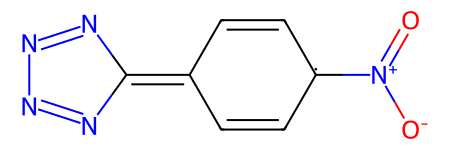

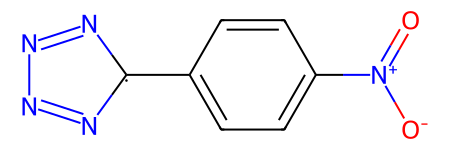

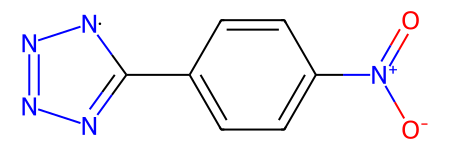

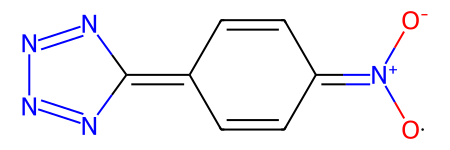

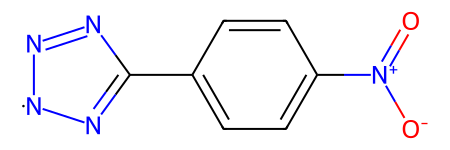

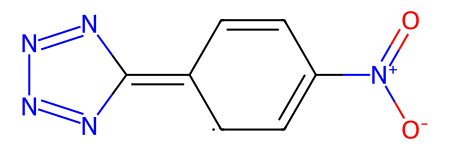

[None, None, None, None, None, None]

In [29]:
smi = "O=[N+]([O-])C1=CC=C(C2=NN=N[N]2)C=C1"
allowed_atoms = ["C", "H", "N", "O"]
n, list_smi, m = generate_resonance_structure_smis(smi, allowed_atoms, get_resonance=True)
display(list_smi)
[display(Chem.MolFromSmiles(smi)) for smi in list_smi]

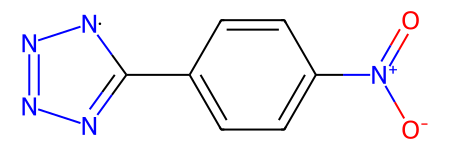

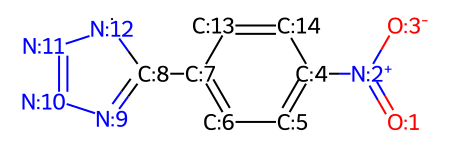

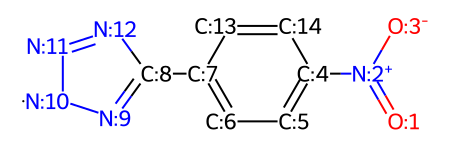

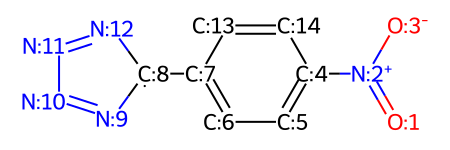

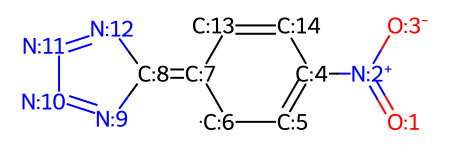

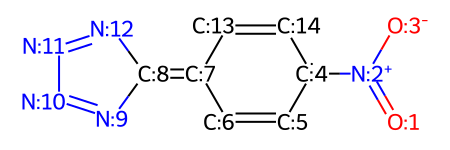

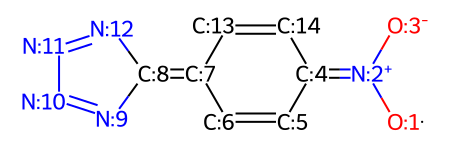

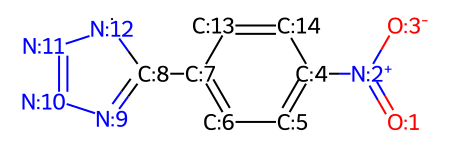

In [30]:
smi = "O=[N+]([O-])C1=CC=C(C2=NN=N[N]2)C=C1"
mol = Molecule().from_smiles(smi)
display(Chem.MolFromSmiles(smi))
mols = mol.generate_resonance_structures()
# [display(mol) for mol in mols]
smis = [mol.to_smiles() for mol in mols] # This is where it all goes wrong
can_smis = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in smis]
# [display(Chem.MolFromSmiles(smi)) for smi in smis]
for smi in smis:
    rdk_mol = Chem.MolFromSmiles(smi)
    
    # Remove atom mappings by converting to SMILES and back to a molecule
    no_map_smi = Chem.MolToSmiles(rdk_mol, isomericSmiles=True, canonical=True)
    fixed_mol = fix_mol(Chem.MolFromSmiles(no_map_smi), fix_spin_multiplicity=True, mult=2)
    
    display(fixed_mol)

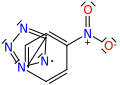

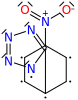

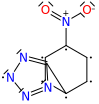

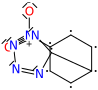

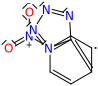

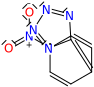

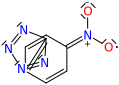

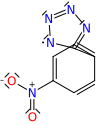

[None, None, None, None, None, None, None]

In [24]:
smi = "O=[N+]([O-])C1=CC=C(C2=NN=N[N]2)C=C1"
mol = Molecule().from_smiles(smi)
display(mol)
mols = mol.generate_resonance_structures()
# [display(mol) for mol in mols]
smis = [mol.to_smiles() for mol in mols] # This is where it all goes wrong
can_smis = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in smis]
[display(Molecule().from_smiles(smi)) for smi in can_smis]

In [ ]:
allowed_atoms = ["C", "H", "N", "O"]
smi = "[O:1]=[N+:2]([O-:3])[c:4]1[c:5]([H:15])[c:6]([H:16])[c:7]([C:8]2=[N:9][N:10]=[N:11][N:12]2)[c:13]([H:17])[c:14]1[H:18]"

parent_smi,reso_smis,reso_num = generate_resonance_structure_smis(smi, allowed_atoms)
reso_num

In [ ]:
smi = "O=[N+]([O-])C1=CC=C(C2=NN=N[N]2)C=C1"
mol = Chem.MolFromSmiles(smi)
mol

In [ ]:
smi = "O=[N+]([O-])c1ccc(C2=NN=N[N]2)cc1"
mol = Chem.MolFromSmiles(smi)
mol

In [ ]:
allowed_atoms = ["C", "H", "N", "O"]
smi = "[O:1]=[N+:2]([O-:3])[c:4]1[c:5]([H:15])[c:6]([H:16])[c:7]([C:8]2=[N:9][N:10]=[N:11][N:12]2)[c:13]([H:17])[c:14]1[H:18]"
p_mol = Chem.MolFromSmiles(smi)
p_mult = get_spin_multiplicity(p_mol)
print(p_mult)
parent_smi,reso_smis,reso_num = generate_resonance_structure_smis(smi, allowed_atoms)
print(reso_num)
print(reso_smis)
display(Chem.MolFromSmiles(parent_smi))
[display(Chem.MolFromSmiles(smi)) for smi in reso_smis]

#can_smi = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in reso_smis]
#print(can_smi)
#[display(Chem.MolFromSmiles(smi)) for smi in can_smi]

# mols = [Chem.MolFromSmiles(reso_smi) for reso_smi in reso_smis]
# for mol in mols:
#     #print(mult)
#     #mol = mol_from_rmg_mol(mol)
#     fixed_mol = fix_mol(mol, fix_spin_multiplicity=True, mult=p_mult)
#     [a.SetAtomMapNum(0) for a in fixed_mol.GetAtoms()]
#     fixed_smiles = Chem.MolToSmiles(fixed_mol)
#     print(fixed_smiles)
#     display(fixed_mol)


In [ ]:
allowed_atoms = ["C", "H", "N", "O"]
smi = "[O:1]=[N+:2]([O-:3])[c:4]1[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]([C:9]2=[C:10]([H:18])[N:11][N:12]=[N:13]2)[c:14]1[H:19]"
parent_smi,reso_smis,_ = generate_resonance_structure_smis(smi, allowed_atoms)
mols = [Chem.MolFromSmiles(reso_smi) for reso_smi in reso_smis]
for mol in mols:
    display(mol)
display(Chem.MolFromSmiles(parent_smi))

## Extracting 20,000 radical resonance molecules from QG

In [ ]:
allowed_atoms = ["C", "H", "N", "O"]
num_species = 21000

subset = radicals.head(n=int(num_species * 3))
outs = Parallel(n_jobs=48)(delayed(generate_resonance_structure_smis)(smi, allowed_atoms) for smi in tqdm(subset[name_smiles].values))

outs = [out for out in outs if out is not None]
outs = outs[:num_species]

results_dict = {
    "parent_smi": [],
    "resonance_smis": [],
    "num_resonance_structures": [],
    #"radical_center": [],
}

for smi, res, num_res in outs:
    results_dict["parent_smi"].extend([smi] * num_res)
    results_dict["resonance_smis"].extend(res)
    results_dict["num_resonance_structures"].extend([num_res] * num_res)
    #results_dict["radical_center"].extend(radical_centers)

results_df = pd.DataFrame(results_dict)
results_df = results_df.merge(subset, left_on="parent_smi", right_on=name_smiles, how="left")
results_df = results_df.drop(columns=[name_smiles])
results_df.columns

In [ ]:
aug_radical_data_set = results_df[['parent_smi', 'resonance_smis', 'num_resonance_structures', 'multiplicity', 'H298', 'H298_kcal']]
radical_data_set = aug_radical_data_set.drop_duplicates(subset=["parent_smi"])
display(aug_radical_data_set.shape)
display(radical_data_set.shape)

### Radical resonance molecules (Check Histogram)

In [ ]:
results_df = radical_data_set

print(f"Max number of resonance structures: {results_df['num_resonance_structures'].max()}")
print(f"Min number of resonance structures: {results_df['num_resonance_structures'].min()}")
count_dict = results_df["num_resonance_structures"].value_counts()

xs = np.arange(1, results_df['num_resonance_structures'].max() + 1)
ys = [count_dict.get(x, 0) for x in xs]
plt.bar(xs, ys)
plt.xticks(xs)


## Extracting 20,000 closed shell resonance molecules from QG

In [ ]:
allowed_atoms = ["C", "H", "N", "O"]
num_species = 40000

subset = closed_shell.head(n=int(num_species * 5))
outs = Parallel(n_jobs=48)(delayed(generate_resonance_structure_smis)(smi, allowed_atoms) for smi in tqdm(subset[name_smiles].values))

outs = [out for out in outs if out is not None]
print(len(outs))
outs = outs[:num_species]

results_dict = {
    "parent_smi": [],
    "resonance_smis": [],
    "num_resonance_structures": [],
    #"radical_center": [],
}

for smi, res, num_res in outs:
    results_dict["parent_smi"].extend([smi] * num_res)
    results_dict["resonance_smis"].extend(res)
    results_dict["num_resonance_structures"].extend([num_res] * num_res)
    #results_dict["radical_center"].extend(radical_centers)

results_df = pd.DataFrame(results_dict)
results_df = results_df.merge(subset, left_on="parent_smi", right_on=name_smiles, how="left")
results_df = results_df.drop(columns=[name_smiles])

results_df.shape

In [ ]:
results_df.columns

In [ ]:
aug_closed_shell_data_set = results_df[['parent_smi', 'resonance_smis', 'num_resonance_structures', 'multiplicity', 'H298', 'H298_kcal']]
closed_shell_data_set = aug_closed_shell_data_set.drop_duplicates(subset=["parent_smi"])
display(closed_shell_data_set.shape)
display(aug_closed_shell_data_set.shape)

### Closed-shell resonance molecules (Check Histogram)

In [ ]:
results_df = closed_shell_data_set

print(f"Max number of resonance structures: {results_df['num_resonance_structures'].max()}")
print(f"Min number of resonance structures: {results_df['num_resonance_structures'].min()}")
count_dict = results_df["num_resonance_structures"].value_counts()

xs = np.arange(1, results_df['num_resonance_structures'].max() + 1)
ys = [count_dict.get(x, 0) for x in xs]
plt.bar(xs, ys)
plt.xticks(xs)

## Extracting 10,000 non-resonace molecules from QG

In [ ]:
allowed_atoms = ["C", "H", "N", "O"]
num_species = 11000

subset = final_data.head(n=int(num_species*2))
outs = Parallel(n_jobs=48)(delayed(generate_resonance_structure_smis)(smi, allowed_atoms, get_resonance=False) for smi in tqdm(subset[name_smiles].values))

outs = [out for out in outs if out is not None]
#print(len(outs))
outs = outs[:num_species]

results_dict = {
    "parent_smi": [],
    "resonance_smis": [],
    "num_resonance_structures": [],
    #"radical_center": [],
}

for smi, res, num_res in outs:
    results_dict["parent_smi"].extend([smi] * num_res)
    results_dict["resonance_smis"].extend(res)
    results_dict["num_resonance_structures"].extend([num_res] * num_res)
    #results_dict["radical_center"].extend(radical_centers)

results_df = pd.DataFrame(results_dict)
results_df = results_df.merge(subset, left_on="parent_smi", right_on=name_smiles, how="left")
results_df = results_df.drop(columns=[name_smiles])

results_df.shape

In [ ]:
aug_non_resonance_data_set = results_df[['parent_smi', 'resonance_smis', 'num_resonance_structures', 'multiplicity', 'H298', 'H298_kcal']]
non_resonance_data_set = aug_non_resonance_data_set.drop_duplicates(subset=["parent_smi"])
display(aug_non_resonance_data_set.shape)
display(non_resonance_data_set.shape)

In [ ]:
aug_non_resonance_data_set.columns

### Non-resonance molecules (Check Histogram)

In [ ]:
results_df = non_resonance_data_set

print(f"Max number of resonance structures: {results_df['num_resonance_structures'].max()}")
count_dict = results_df["num_resonance_structures"].value_counts()

xs = np.arange(1, results_df['num_resonance_structures'].max() + 1)
ys = [count_dict.get(x, 0) for x in xs]
plt.bar(xs, ys)
plt.xticks(xs)

## Concatenating the three data sets into one final data set

In [35]:
aug_radical_data_set["subset"] = "res_radical"
aug_closed_shell_data_set["subset"] = "res_closed_shell"
aug_non_resonance_data_set["subset"] = "non_resonance"

aug_data_set = pd.concat([aug_radical_data_set, aug_closed_shell_data_set, aug_non_resonance_data_set])
aug_data_set = aug_data_set.reset_index(drop=True)
#aug_data_set.groupby("parent_smi")['resonance_smis'].apply(lambda x: x.drop_duplicates().reset_index(drop=True))
#repeated_values = aug_data_set['resonance_smis'].value_counts()[aug_data_set['resonance_smis'].value_counts() > 1]
aug_data_set = aug_data_set.drop_duplicates(subset=["resonance_smis"])
#repeated_values.shape

In [ ]:
aug_data_set["rdkit_mol"] = aug_data_set["parent_smi"].swifter.apply(Chem.MolFromSmiles)
aug_data_set["num_heavy_atoms"] = aug_data_set["rdkit_mol"].swifter.apply(CalcNumHeavyAtoms)
aug_data_set["mol_wt"] = aug_data_set["rdkit_mol"].swifter.apply(Descriptors.MolWt)
aug_data_set["num_rings"] = aug_data_set["rdkit_mol"].swifter.apply(CalcNumRings)
aug_data_set["num_rotatable_bonds"] = aug_data_set["rdkit_mol"].swifter.apply(CalcNumRotatableBonds)
aug_data_set["num_aromatic_rings"] = aug_data_set["rdkit_mol"].swifter.apply(CalcNumAromaticRings)
aug_data_set["mol_graph_diameter"] = aug_data_set["rdkit_mol"].swifter.apply(lambda x: int(Chem.GetDistanceMatrix(Chem.AddHs(x)).max()))

In [ ]:
aug_data_set["weights"] = 1 / aug_data_set["num_resonance_structures"]
#aug_data_set.to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/aug_data_set.csv", index=False)
repeated_values = aug_data_set['resonance_smis'].value_counts()[aug_data_set['resonance_smis'].value_counts() > 1]
repeated_values

In [ ]:
data_set = aug_data_set.drop_duplicates(subset=["parent_smi"])
data_set = data_set.reset_index(drop=True)
#data_set.to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/data_set.csv", index=False)
#data_set = data_set.drop_duplicates(subset = ["resonance_smis"])
repeated_values = data_set['resonance_smis'].value_counts()[data_set['resonance_smis'].value_counts() > 1]
print(data_set.shape)
repeated_values.shape

## Randomly splitting the data set into train, val, test (80, 10, 10) 

In [ ]:
cleaned_data_set = data_set[data_set["subset"] == "res_radical"].sample(n=20000, random_state=699)
cleaned_data_set = pd.concat([cleaned_data_set, data_set[data_set["subset"] == "res_closed_shell"].sample(n=20000, random_state=69)])
cleaned_data_set = pd.concat([cleaned_data_set, data_set[data_set["subset"] == "non_resonance"].sample(n=10000, random_state=69)])
display(cleaned_data_set)
#cleaned_data_set.to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/cleaned_data_set.csv", index =False)
cleaned_aug_data_set = cleaned_data_set[["parent_smi"]].merge(aug_data_set, on="parent_smi", how="left")
#cleaned_aug_data_set.to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/cleaned_aug_data_set.csv", index=False)
display(cleaned_aug_data_set)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

H298 = final_data['H298_kcal']
sns.histplot(H298, kde=True, color='blue', label='Data 1', bins=100)

In [ ]:
smi = 'CC(=O)N1CC1[C]=O'
mol = Chem.MolFromSmiles(smi)
mol

In [ ]:
smi = 'CC(C)C([O])=C1CC1'
mol = Chem.MolFromSmiles(smi)
mol

In [ ]:
smi = '[O]C1=C2OC(C=C1)C2O'
mol = Chem.MolFromSmiles(smi)
mol

In [44]:
import os
from sklearn.model_selection import train_test_split

data_set_shuffled = cleaned_data_set.sample(frac=1, random_state=21)
subset_names = ["res_radical", "res_closed_shell", "non_resonance"]
data_set_train = pd.DataFrame()
data_set_val = pd.DataFrame()
data_set_test = pd.DataFrame()
for subset_name in subset_names:
    subset = data_set_shuffled[data_set_shuffled["subset"] == subset_name]
    subset_train, subset_test = train_test_split(subset, test_size = 0.2, random_state=21) 
    subset_test, subset_val = train_test_split(subset_test, test_size = 0.5, random_state=21)
    #print(subset_test.shape)
    data_set_train = pd.concat([subset_train, data_set_train])
    data_set_val = pd.concat([subset_val, data_set_val])
    data_set_test = pd.concat([subset_test, data_set_test])


data_set_train = data_set_train.reset_index(drop=True)
data_set_val = data_set_val.reset_index(drop=True)
data_set_test = data_set_test.reset_index(drop=True)



#print(data_set_test.shape)
#print(data_set_val.iloc[69])
#data_set_test = data_set_test.append(data_set_val.iloc[69], ignore_index=True)
#data_set_test = pd.concat([data_set_test, pd.DataFrame(data_set_val.iloc[69]).T], ignore_index=True)
#data_set_val.drop(69, inplace=True)


# data_set_train[['resonance_smis', 'H298_kcal']].to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run1/data_set_train.csv", index=False)
# data_set_val[['resonance_smis','H298_kcal']].to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run1/data_set_val.csv", index=False)
# data_set_test[['resonance_smis', 'H298_kcal']].to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run1/data_set_test.csv", index=False)
# print(data_set_val.shape, data_set_train.shape, data_set_test.shape)


aug_data_set_test = data_set_test[["parent_smi"]].merge(aug_data_set, on="parent_smi", how="left")
# aug_data_set_test[['resonance_smis', 'H298_kcal']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run2/aug_data_set_test.csv',index=False)
# aug_data_set_test[['resonance_smis', 'H298_kcal']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run3/aug_data_set_test.csv',index=False)
# aug_data_set_test[['resonance_smis', 'H298_kcal','weights']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run4/aug_data_set_test_weights.csv',index=False)
# aug_data_set_test[['parent_smi','resonance_smis', 'H298_kcal']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/aug_data_set_test_labels.csv',index=False)

aug_data_set_train = data_set_train[['parent_smi']].merge(aug_data_set, on='parent_smi', how='left')
# aug_data_set_train[['resonance_smis', 'H298_kcal']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run3/aug_data_set_train.csv',index=False)
# aug_data_set_train[['resonance_smis', 'H298_kcal','weights']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run4/aug_data_set_train_weights.csv',index=False)

aug_data_set_val = data_set_val[['parent_smi']].merge(aug_data_set, on='parent_smi', how='left')
# aug_data_set_val[['resonance_smis', 'H298_kcal']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run3/aug_data_set_val.csv',index=False)
# aug_data_set_val[['resonance_smis', 'H298_kcal', 'weights']].to_csv('/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run4/aug_data_set_val_weights.csv',index=False)

aug_data_set_test_rnd = aug_data_set_test.groupby("parent_smi").sample(n=1, random_state=12)
# aug_data_set_test_rnd[['resonance_smis', 'H298_kcal']].to_csv("/home/akshatz/bond_order_free/rigr_h298_50k/dataset/run5/aug_data_set_test_rnd.csv", index=False)

final_data_set =  pd.concat([data_set_test, data_set_train, data_set_val])
final_aug_data_set = pd.concat([aug_data_set_test, aug_data_set_train, aug_data_set_val])
final_test = data_set_test
final_aug_test = aug_data_set_test
final_rnd_test = aug_data_set_test_rnd

# final_data_set.to_csv("dataset/all_data_set.csv", index=False)
# final_aug_data_set.to_csv("dataset/all_aug_data_set.csv", index=False)

# final_data_set[['resonance_smis', 'H298_kcal']].to_csv("dataset/final_data_set.csv", index=False)
# final_aug_data_set[['resonance_smis', 'H298_kcal', 'weights']].to_csv("dataset/final_aug_data_set.csv", index=False)
# final_test[['resonance_smis', 'H298_kcal']].to_csv("dataset/final_test.csv", index=False)
# final_aug_test[['resonance_smis', 'H298_kcal']].to_csv("dataset/final_aug_test.csv", index=False)
# final_rnd_test[['resonance_smis', 'H298_kcal']].to_csv("dataset/final_rnd_test.csv", index=False)

In [45]:
downsample_sizes = [20_000, 10_000, 5000, 2000, 1000, 500, 200]
downsample_folder_names = ["20k", "10k", "5k", "2k", "1k", "500", "200", "100", "50"]
full_train = data_set_train
full_val = data_set_val

for downsample_size, downsample_folder_name in zip(downsample_sizes, downsample_folder_names):
    frac = downsample_size / len(full_train.index)

    downsample_train = full_train.groupby("subset").sample(frac=frac, random_state=21)
    downsample_val = full_val.groupby("subset").sample(frac=frac, random_state = 21)

    # downsample_train[['resonance_smis', 'H298_kcal']].to_csv(f"../rigr_h298_{downsample_folder_name}/dataset/run1/data_set_train.csv", index=False)
    # downsample_val[['resonance_smis','H298_kcal']].to_csv(f"../rigr_h298_{downsample_folder_name}/dataset/run1/data_set_val.csv", index=False)
    # data_set_test[['resonance_smis', 'H298_kcal']].to_csv(f"../rigr_h298_{downsample_folder_name}/dataset/run1/data_set_test.csv", index=False)

    # aug_data_set_test[['resonance_smis', 'H298_kcal','weights']].to_csv(f'../rigr_h298_{downsample_folder_name}/dataset/run4/aug_data_set_test_weights.csv',index=False)

    aug_downsample_train = downsample_train[['parent_smi']].merge(aug_data_set, on='parent_smi', how='left')
    # aug_downsample_train[['resonance_smis', 'H298_kcal','weights']].to_csv(f'../rigr_h298_{downsample_folder_name}/dataset/run4/aug_data_set_train_weights.csv',index=False)

    aug_downsample_val = downsample_val[['parent_smi']].merge(aug_data_set, on='parent_smi', how='left')
    # aug_downsample_val[['resonance_smis', 'H298_kcal', 'weights']].to_csv(f'../rigr_h298_{downsample_folder_name}/dataset/run4/aug_data_set_val_weights.csv',index=False)


    full_train = downsample_train
    full_val = downsample_val